<a href="https://colab.research.google.com/github/Julian6262/the_founder/blob/main/%D0%94%D0%97-36.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:

**Задание 1. На 3 балла:**

1. Ваша задача, используя знания текущего урока обучить модель переводить предложения с английского языка на португальский.

2. В качестве словаря для англо-португальского перевода используйте набор данных из параллельных пар предложений на разных языках http://www.manythings.org/anki/ разделенных табуляцией.

3. Расщепите данные на обучающую выборку и выборку для тестирования модели.

4. Продемонстрируйте работу модели на 10 примерах из тестовой выборки. Сформируйте таблицу из трех колонок: английская фраза из тестовой выборки, португальский перевод из тестовой выборки, предсказанный перевод на португальский язык.

**Задание 2. На 4 балла:**

1. Вам необходимо выполнить задание на 3 балла, изменив механизм токенизации.

2. Для этого необходимо самостоятельно познакомиться с BPE-токенизацией (Byte Pair Encoding) и применить ее. Можно использовать как токенизацию по тексту, так и byte-level BPE-токенизацию по байтовым представлениям (именно так происходит токенизация у GPT моделей от OpenAI).

**ВАЖНО**. Даже если вы не планируете делать задание на 4 балла, хотябы бегло изучите как работает byte-level BPE-токенизация, именно она позволяет сжимать словарь до всего-лишь ~50k токенов при том, что с его помощью всё ещё можно выразить любое слово на любом языке мира и даже эмодзи! Тем более Keras уже содержит готовые токенизаторы и довольно неплохое их описание.

**Задание 3. На 5 балла:**

Это творческое задание нацелено на проработку очень важного навыка любого программиста: умение реализовать проект по фрагментам кода от предыдущей команды.

Представьте, что вы пришли в новую компанию и вам дали следующий код, с помощью которого предыдущая команда, генерировала описания к изображениям:

Ваша задача, как тимлида проекта, самостоятельно, не прибегая к помощи куратора:
1. Разобраться в работе кода.
2. Найти датасет с изображениями и подписи к ним.
3. Обучить модель по картинкам делать описание.
4. Продемонстрировать работу модели.

In [ ]:
import numpy as np
import pandas as pd
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Embedding, RepeatVector
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.applications.inception_v3 import InceptionV3
from keras.applications.inception_v3 import preprocess_input
from keras.preprocessing import image

from keras.preprocessing.image import  load_img

import matplotlib.pyplot as plt
%matplotlib inline

import pickle

In [ ]:
!wget https://storage.yandexcloud.net/dba-storage/archive.zip
!wget https://storage.yandexcloud.net/dba-storage/image_features.pkl

!unzip -qo "archive.zip"

--2024-08-29 08:49:32--  https://storage.yandexcloud.net/dba-storage/archive.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1112971163 (1.0G) [application/x-zip-compressed]
Saving to: ‘archive.zip.1’

archive.zip.1       100%[===================>]   1.04G  75.8MB/s    in 16s     

2024-08-29 08:49:49 (67.1 MB/s) - ‘archive.zip.1’ saved [1112971163/1112971163]

--2024-08-29 08:49:49--  https://storage.yandexcloud.net/dba-storage/image_features.pkl
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 127795363 (122M) [application/x-www-form-urlencoded]
Saving to: ‘image_features.pkl’

image_feat

In [ ]:
# загрузка предобученной модели InceptionV3
base_model = InceptionV3(weights='imagenet')
model = Model(base_model.input, base_model.layers[-2].output)

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(299, 299))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x)
    return features

In [ ]:
# чтение данных
captions_data_path = 'captions.txt'
images_path = 'Images/'
load_features = True

SOS = '< START >'  # токен начала последовательсти
EOS = '< END >'  # токен окончания последовательсти

In [ ]:
captions = open(captions_data_path, 'r').read().strip().split('\n')

# убираем шапку
captions = captions[1:]

In [ ]:
captions_dict = dict()

for line in captions:
    img_id, caption = line.split('.jpg,')
    img_id = img_id + '.jpg'

    if img_id not in captions_dict:
        # captions_dict[img_id] = list()
        captions_dict[img_id] = caption.lower()

In [ ]:
image_ids = []
captions_list = []
for img_id, caption in captions_dict.items():
    image_ids.append(img_id)
    captions_list.append(SOS + caption + EOS)

len(image_ids)

8091

In [ ]:
z = 7800

train_image = image_ids[:z]
train_captions = captions_list[:z]

test_image = image_ids[z:]
test_captions = captions_list[z:]

In [ ]:
print(len(train_image))
print(len(train_captions))

7800
7800


In [ ]:
len(test_image)

291

In [ ]:
del captions, captions_list, image_ids, captions_dict

In [ ]:
# токенизация
caption_tokenizer = Tokenizer()
caption_tokenizer.fit_on_texts(train_captions)
caption_sequences = caption_tokenizer.texts_to_sequences(train_captions)
caption_word_index = caption_tokenizer.word_index

# паддинг последовательностей
max_len_caption = max([len(txt) for txt in caption_sequences])

decoder_input_data = pad_sequences(caption_sequences, maxlen=max_len_caption, padding='post')

# смещение на один токен вправо для decoder_target_data
decoder_target_data = np.zeros((len(train_captions), max_len_caption, len(caption_word_index) + 1), dtype='float32')
for i, seqs in enumerate(caption_sequences):
    for t, token in enumerate(seqs):
        if t > 0:
            decoder_target_data[i, t - 1, token] = 1.0

In [ ]:
# экстракция признаков изображений
if not load_features:
    image_features = np.zeros((len(train_image), 2048))
    for i, img_id in enumerate(train_image):
        img_path = images_path + img_id
        image_features[i] = extract_features(img_path, model)

    # Сохраним признаки в файл
    with open("image_features.pkl", "wb") as file:
        pickle.dump(image_features, file)

else:
    # Загрузим признаки из файла
    with open("image_features.pkl", "rb") as file:
        image_features = pickle.load(file)

In [ ]:
len(image_features)

7800

In [ ]:
# гиперпараметры
latent_dim = 256
num_decoder_tokens = len(caption_word_index) + 1

# Кодировщик
encoder_inputs = Input(shape=(2048,))
encoder_v = RepeatVector(latent_dim)(encoder_inputs)
encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_v)
encoder_states = [state_h, state_c]

# Декодер
decoder_inputs = Input(shape=(None,))
decoder_embedding = Embedding(input_dim=num_decoder_tokens, output_dim=latent_dim)(decoder_inputs)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
decoder_dense = Dense(num_decoder_tokens, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Модель Seq2Seq
seq2seq_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
seq2seq_model.compile(optimizer='adam', loss='categorical_crossentropy')

In [ ]:
# seq2seq_model.summary()

In [ ]:
# Обучение модели Seq2Seq
seq2seq_model.fit([image_features, decoder_input_data], decoder_target_data, batch_size=64, epochs=100, validation_split=0.2)

Epoch 1/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - loss: 2.1339 - val_loss: 1.8411
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - loss: 1.8165 - val_loss: 1.8063
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - loss: 1.7727 - val_loss: 1.7772
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - loss: 1.7556 - val_loss: 1.7461
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - loss: 1.7177 - val_loss: 1.7140
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - loss: 1.6843 - val_loss: 1.6691
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - loss: 1.6142 - val_loss: 1.6324
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - loss: 1.5882 - val_loss: 1.5898
Epoch 9/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - loss: 1.5528 - val_loss: 1.5557
Epoch 10/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - loss: 1.5151 - val_loss: 1.5240
Epoch 11/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - loss: 1.4740 - val_loss: 1.4969
Epoch 12/100
98/98 ━━━━━━━━━━━

In [ ]:
# Рабочий режим сети (Inference)

# Создадим модель кодировщика
# На входе будут закодированные вопросы, на выходе состояния state_h, state_c
encoder_model = Model(encoder_inputs, encoder_states)

# Создадим модель декодировщика
decoderStateInput_h = Input(shape=(latent_dim,))  # входной слой для state_h
decoderStateInput_c = Input(shape=(latent_dim,))  # входной слой для state_c

# Соберем оба входа вместе
decoderStatesInputs = [decoderStateInput_h, decoderStateInput_c]

# Берём ответы, прошедшие через эмбединг, вместе с состояниями и подаём LSTM cлою
decoderOutputs, state_h, state_c = decoder_lstm(decoder_embedding, initial_state=decoderStatesInputs)

# LSTM даст нам новые состояния
decoderStates = [state_h, state_c]

# И ответы, которые мы пропустим через полносвязный слой с софтмаксом
decoderOutputs = decoder_dense(decoderOutputs)

# Определим модель декодировщика
decoderModel = Model([decoder_inputs] + decoderStatesInputs, [decoderOutputs] + decoderStates)

In [ ]:
# Функция генерации подписи
def generate_caption(image_path, model, caption_tokenizer, max_len_caption):
    targetSeq = np.zeros((1, 1))  # объявляем последовательность
    targetSeq[0, 0] = caption_tokenizer.word_index['start']  # на начальном этапе последовательность содержит только токен начала последовательности
    stop = False  # признак окончания генерации последоватнльности токенов
    decoded_answer = ''  # строка с результатом предсказания

    image_features = extract_features(image_path, model)
    statesValues = encoder_model.predict(image_features)  # получение контектного вектора из кодировщика

    # пока не сработало стоп-условие
    while not stop:
        # В модель декодера подадим пустую последовательность со словом 'start' и состояния
        decOutputs, h, c = decoderModel.predict([targetSeq] + statesValues)

        # Получим индекс предсказанного слова.
        predictIndex = np.argmax(decOutputs[0, 0, :])

        # Создаем переменную для хранения предсказанного слова на русском языке
        predictWord = None

        # Переберем в цикле все индексы токенайзера для поиска слова по индексу
        for word, index in caption_tokenizer.word_index.items():

            # Если нашли слово по индексу
            if predictIndex == index:

                # Найденное слово по индексу в словаре добавляем к итоговому ответу
                decoded_answer += f' {word}'

                # Найденное слово добавляем в предсказанное слово
                predictWord = word

        # Если найденное слово является признаком окончания генерации 'end' или ответ превышает максимальную длину ответа, то останавливаем генерацию
        if predictWord == 'end' or len(decoded_answer.split()) > max_len_caption:

            stop = True  # устанавливаем признак окончания генерации
        # Обновляем входной токен для следующего шага генерации

        targetSeq = np.zeros((1, 1))
        targetSeq[0, 0] = predictIndex

        # Обновляем состояния ячейки и переходим к следующему шагу цикла
        statesValues = [h, c]

    return decoded_answer

< START >a black and white dog jumping into the air .< END >


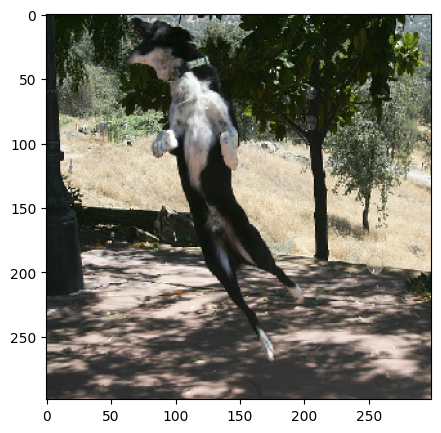

In [ ]:
z = 1

img_id = test_image[z]
caption = test_captions[z]

img_path = images_path + img_id

plt.figure(figsize=(5, 5))
img = np.array(load_img(img_path, target_size=(299, 299)))

plt.imshow(img)

print(caption)

In [ ]:
caption = generate_caption(img_path, model, caption_tokenizer, max_len_caption)
print(caption.replace(' end', ''))

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
 a black and white dog is running through the grass


< START >a black and brown dog running across the grass .< END >


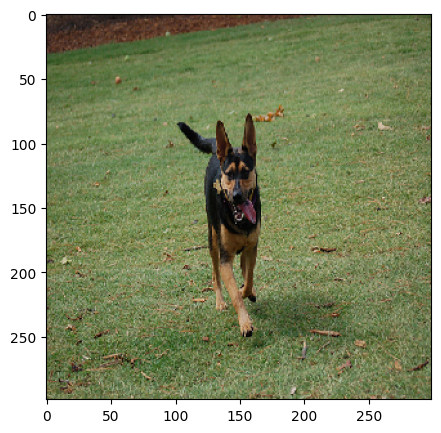

In [ ]:
z = 50

img_id = test_image[z]
caption = test_captions[z]

img_path = images_path + img_id

plt.figure(figsize=(5, 5))
img = np.array(load_img(img_path, target_size=(299, 299)))

plt.imshow(img)

print(caption)

In [ ]:
caption = generate_caption(img_path, model, caption_tokenizer, max_len_caption)
print(caption.replace(' end', ''))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
 a black dog is running through the water
